#  Neural Machine Translation BERT




## Setup

In [5]:
!pip install torch==2.4.1 --index-url https://download.pytorch.org/whl/cu118
!pip install pytorch-lightning==2.2.4
!pip install torchmetrics
!pip install sacrebleu
!pip install sentencepiece
!pip install datasets
!pip install spacy
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm

  Using cached spacy-3.8.14-cp310-cp310-win_amd64.whl.metadata (28 kB)
  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached murmurhash-1.0.15-cp310-cp310-win_amd64.whl.metadata (2.3 kB)
  Using cached cymem-2.0.13-cp310-cp310-win_amd64.whl.metadata (9.9 kB)
  Using cached preshed-3.0.13-cp310-cp310-win_amd64.whl.metadata (5.4 kB)
  Using cached thinc-8.3.13-cp310-cp310-win_amd64.whl.metadata (15 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached srsly-2.5.3-cp310-cp310-win_amd64.whl.metadata (20 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached confection-1.3.3-py3-none-any.whl.metadata (19 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached annotated_types-0.7.0-

In [20]:
!pip install transformers

## Imports

In [3]:
!pip install -q --upgrade tqdm datasets

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

from datasets import load_dataset

import spacy
import numpy as np

import random
import math
import time
from collections import Counter


## Reproducibility

In [7]:
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [8]:
# Read the text file
def extract_sent(f_path):
    with open(f_path, "r", encoding="utf-8") as f:
        lines = f.read().splitlines()
        return lines

In [9]:
import os
src = r"C:\Users\Saloni_major\Desktop\Delhidataset\hi_mr"
mr_train = extract_sent(os.path.join(src, "train_mr.txt"))
mr_test = extract_sent(os.path.join(src, "test_mr.txt"))
hi_train = extract_sent(os.path.join(src, "train_hi.txt"))
hi_test = extract_sent(os.path.join(src, "test_hi.txt"))

In [10]:
print(hi_train[0])
print(mr_train[0])

print(len(hi_train))
print(len(mr_train))


print(len(hi_test))
print(len(mr_test))

इस  प्रयोग  को  नित्य  करने  से  दाँत  नहीं  सड़ते  । 
हा  प्रयोग  रोज  केल्याने  दात  खराब  होत  नाही  . 
241847
241847
10390
10390


In [14]:
# import spacy

# spacy_hi = spacy.blank("hi")
# spacy_mr = spacy.blank("mr")

# def tokenize_hi(text):
#     return [tok.text.lower() for tok in spacy_hi.tokenizer(text)]

# def tokenize_mr(text):
#     return [tok.text.lower() for tok in spacy_mr.tokenizer(text)]

In [11]:
import sentencepiece as spm

# Train SentencePiece on your raw text files
# 8000 vocab size is good for Hindi/Marathi — tune as needed
spm.SentencePieceTrainer.train(
    input=r"C:\Users\Saloni_major\Desktop\Delhidataset\hi_mr\train_hi.txt",
    model_prefix="spm_hi",
    vocab_size=30000,
    character_coverage=0.9995,  # high coverage for Devanagari script
    model_type="bpe"
)

spm.SentencePieceTrainer.train(
    input=r"C:\Users\Saloni_major\Desktop\Delhidataset\hi_mr\train_mr.txt",
    model_prefix="spm_mr",
    vocab_size=30000,
    character_coverage=0.9995,
    model_type="bpe"
)

sp_hi = spm.SentencePieceProcessor(model_file="spm_hi.model")
sp_mr = spm.SentencePieceProcessor(model_file="spm_mr.model")

def tokenize_hi(text):
    return sp_hi.encode(text, out_type=str)

def tokenize_mr(text):
    return sp_mr.encode(text, out_type=str)

In [ ]:
# !pip uninstall transformers tokenizers huggingface-hub -y
# # !pip install transformers

In [28]:
!pip show sentencepiece transformers tokenizers torch

Name: sentencepiece
Version: 0.2.1
Summary: Unsupervised text tokenizer and detokenizer.
Home-page: https://github.com/google/sentencepiece
Author: 
Author-email: Taku Kudo <taku@google.com>
License: 
Location: c:\users\saloni_major\anaconda3\envs\mt6_s\lib\site-packages
Requires: 
Required-by: 
---
Name: transformers
Version: 4.40.0
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: c:\users\saloni_major\anaconda3\envs\mt6_s\lib\site-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: 
---
Name: tokenizers
Version: 0.19.1
Summary: 
Home-page: https://github.com/huggingface/tokenizers
Author: Anthony M

In [30]:

!pip uninstall transformers==4.40.0 tokenizers==0.19.1 huggingface-hub==0.23.0

^C


In [1]:
pip install transformers==4.46.0 tokenizers==0.20.3 huggingface-hub==0.26.0

  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached regex-2026.5.9-cp310-cp310-win_amd64.whl.metadata (41 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 10.0/10.0 MB 89.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 68.4 MB/s  0:00:00
Using cached fsspec-2026.4.0-py3-none-any.whl (203 kB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
Using cached regex-2026.5.9-cp310-cp310-win_amd64.whl (278 kB)
Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl (341 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using ca

Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet


In [ ]:
# Build vocabulary from scratch 
class Vocabulary:
    def __init__(self, min_freq=2):
        self.min_freq = min_freq
        self.itos = ['<unk>', '<pad>', '<sos>', '<eos>']
        self.stoi = {tok: i for i, tok in enumerate(self.itos)}

    def build(self, tokenized_sentences):
        counter = Counter(tok for sent in tokenized_sentences for tok in sent)
        for word, freq in counter.items():
            if freq >= self.min_freq and word not in self.stoi:
                self.stoi[word] = len(self.itos)
                self.itos.append(word)
        return self

    def __len__(self):
        return len(self.itos)

    def encode(self, tokens):
        return [self.stoi.get(t, self.stoi['<unk>']) for t in tokens]

# Tokenize once
hi_train_1 = [tokenize_hi(ex) for ex in hi_train]
mr_train_1 = [tokenize_mr(ex) for ex in mr_train]

SRC_VOCAB = Vocabulary(min_freq=2).build(hi_train_1)
TRG_VOCAB = Vocabulary(min_freq=2).build(mr_train_1)

print(f"SRC vocab size: {len(SRC_VOCAB):,}")
print(f"TRG vocab size: {len(TRG_VOCAB):,}")

SRC vocab size: 28,565
TRG vocab size: 29,982


In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

def extract_bert_embeddings(model_name, vocab):
    
    print(f"Loading {model_name}...")
    bert_tokenizer = AutoTokenizer.from_pretrained(model_name)
    bert_model     = AutoModel.from_pretrained(model_name)
    bert_model.eval()

    vocab_size  = len(vocab)
    embed_dim   = bert_model.config.hidden_size  # 768 for BERT base
    embeddings  = torch.zeros(vocab_size, embed_dim)

    # Random init as fallback for unknown tokens
    torch.nn.init.normal_(embeddings, mean=0, std=0.01)

    with torch.no_grad():
        for token, idx in vocab.stoi.items():
            # Skip special tokens,keep them randomly initialized
            if token in ['<unk>', '<pad>', '<sos>', '<eos>']:
                continue

            bert_ids = bert_tokenizer.encode(token, add_special_tokens=False)
            if len(bert_ids) == 0:
                continue

            # Average subword embeddings if BERT splits the token further
            input_ids   = torch.tensor([bert_ids])
            output      = bert_model(input_ids)
            token_embed = output.last_hidden_state[0].mean(dim=0)  # [768]
            embeddings[idx] = token_embed

    print(f"  Vocab size: {vocab_size}, Embed dim: {embed_dim}")
    return embeddings

hi_embeddings = extract_bert_embeddings("l3cube-pune/hindi-bert-v2",   SRC_VOCAB)
mr_embeddings = extract_bert_embeddings("l3cube-pune/marathi-bert-v2", TRG_VOCAB)

Loading l3cube-pune/hindi-bert-v2...


Some weights of BertModel were not initialized from the model checkpoint at l3cube-pune/hindi-bert-v2 and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Vocab size: 28565, Embed dim: 768
Loading l3cube-pune/marathi-bert-v2...


Some weights of BertModel were not initialized from the model checkpoint at l3cube-pune/marathi-bert-v2 and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Vocab size: 29982, Embed dim: 768


In [15]:
SRC_VOCAB

In [16]:
import pandas as pd
df = pd.DataFrame()
df['hi'] = hi_train
df['mr'] = mr_train

In [17]:
df_train = df[:200000][:].reset_index(drop=True)

In [18]:
df_val = df[200000:][:].reset_index(drop=True)

In [19]:
df_val

,hi,mr
0,इस प्रकार नबियों के विषय में सेनाओं का यहुवाह ...,सर्वशक्तिमान परमेश्वर संदेष्ट्यांबद्दल म्हणतो ...
1,"इस प्रकार आर्मिस के याहवे कहते हैं, भविष्यद्वक...",सर्वशक्तिमान परमेश्वर ह्या गोष्टी सांगतो : “ ह...
2,वे उन लोगों से लगातार कहते हैं जो मुझे घृणा कर...,काही लोक परमेश्वराकडून आलेल्या खऱ्या संदेशाला ...
3,"यहुवे की परिषद में कौन खड़ा है, कि उसे अपना वच...",पण ह्या संदेष्ट्यांमधील कोणीही स्वर्गातील देवा...
4,"देखो, याह्वेह का तूफान, उसका क्रोध आगे बढ़ गया...",आता परमेश्वराकडून वादळाप्रमाणे शिक्षा येईल . प...
...,...,...
41842,"और आत्मा और दुल्हन कहते हैं, आओ। और सुनने वाला...","आत्मा आणि नवरी असे म्हणतात की , “ ये ! आणि जो ..."
41843,"क्योंकि मैं हर उस आदमी की गवाही देता हूं, जो इ...",या पुस्तकात भविष्याकाळाबाबत नमूद केलेली वचने ज...
41844,और यदि कोई व्यक्ति इस भविष्यवाणी की पुस्तक के ...,आणि जो कोणी भविष्याकाळाबाबत संदेश देणाऱ्या या ...
41845,"वह जो इन बातों को स्पष्ट करता है, निश्चित रूप ...","जो येशू या गोष्टीविषयी साक्ष देतो , तो म्हणतो ..."


In [20]:
import pandas as pd
df_test = pd.DataFrame()
df_test['hi'] = hi_test
df_test['mr'] = mr_test

In [21]:
df_test

,hi,mr
0,यदि श्वास प्रणालिका में सूजन आ जाये तब ...,जर श्वासनलिकेला सूज आली तरीही रक्त तोंडावाटे ब...
1,यदि कान में पड़ी हुई चीज़ को तुरंत सूज...,जर कानात पडलेल्या वस्तुला लगेच सूज इत्यादीमुळे...
2,नाश्ता नहीं करने पर आपका उपापचय दोपहर के भोजन ...,नाश्ता केल्यानंतर तुमचा उपापचय दुपारच्या जेवणा...
3,राजस्थान की पहली महिला पायलट नम्रता भट्ट...,राजस्थानची पहिली स्त्री पायलट नम्रता भट...
4,प्रजनन एवं बाल स्वास्थ्य कार्यक्रम के अन...,प्रजनन आणि बाल आरोग्य योजनेअंतर्गत महिला ...
...,...,...
10385,"जब वे रेफ़िडिम से चले गए थे, और सिनाई के जंगल ...",ते लोक रफीदीम सोडून सीनायच्या रानात आले होते ;...
10386,"मूसा भगवान के पास गया, और यहुव ने उसे पहाड़ से...",मग मोशे पर्वतावर देवाला भेटावयास गेला तो पर्वत...
10387,&#39;तुमने देखा कि मैंने मिस्रियों के साथ क्या...,‘ मी माझ्या शत्रुंचे काय करतो ते तुम्ही पाहिले...
10388,"अब इसलिए, यदि तुम मेरी वाणी का वास्तव में पालन...",म्हणून मी आता तुम्हाला सांगतो की तुम्ही माझ्या...


In [ ]:
# Dataset & DataLoader 
class TranslationDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, src_vocab, trg_vocab, tokenize_src, tokenize_trg):
        self.data = hf_dataset
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.tokenize_src = tokenize_src
        self.tokenize_trg = tokenize_trg

    def __len__(self):
        return len(self.data)

    # def __getitem__(self, idx):
    #     src_tokens = ['<sos>'] + self.tokenize_src(self.data[idx]['hi']) + ['<eos>']
    #     trg_tokens = ['<sos>'] + self.tokenize_trg(self.data[idx]['mr']) + ['<eos>']
    #     src_ids = torch.tensor(self.src_vocab.encode(src_tokens), dtype=torch.long)
    #     trg_ids = torch.tensor(self.trg_vocab.encode(trg_tokens), dtype=torch.long)
    #     return src_ids, trg_ids
    def __getitem__(self, idx):
        # Use .iloc[idx] instead of [idx] for pandas DataFrame row access
        row = self.data.iloc[idx]
        src_tokens = ['<sos>'] + self.tokenize_src(row['hi']) + ['<eos>']
        trg_tokens = ['<sos>'] + self.tokenize_trg(row['mr']) + ['<eos>']
        src_ids = torch.tensor(self.src_vocab.encode(src_tokens), dtype=torch.long)
        trg_ids = torch.tensor(self.trg_vocab.encode(trg_tokens), dtype=torch.long)
        return src_ids, trg_ids

def collate_fn(batch):
    src_batch, trg_batch = zip(*batch)
    # Pad and transpose to [seq_len, batch_size] to match original code
    src_padded = pad_sequence(src_batch, padding_value=SRC_VOCAB.stoi['<pad>']).long()
    trg_padded = pad_sequence(trg_batch, padding_value=TRG_VOCAB.stoi['<pad>']).long()
    return src_padded, trg_padded

BATCH_SIZE = 16
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

train_dataset = TranslationDataset(df_train, SRC_VOCAB, TRG_VOCAB, tokenize_hi, tokenize_mr)
valid_dataset = TranslationDataset(df_val, SRC_VOCAB, TRG_VOCAB, tokenize_hi, tokenize_mr)
test_dataset  = TranslationDataset(df_test,  SRC_VOCAB, TRG_VOCAB, tokenize_hi, tokenize_mr)

train_iterator = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
valid_iterator = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_iterator  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_iterator)} | Valid batches: {len(valid_iterator)}")

Device: cuda
Train batches: 12500 | Valid batches: 2616


## Building the Seq2Seq Model

Four components:
1. **Encoder** — Bidirectional LSTM
2. **Attention** — alignment model
3. **Decoder** — LSTM with attention
4. **Seq2Seq** — ties them together


### Encoder

In [23]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.LSTM(emb_dim, enc_hid_dim, bidirectional=True)
        self.fc = nn.Linear(enc_hid_dim * 2, dec_hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src = [src len, batch size]
        embedded = self.dropout(self.embedding(src))
        # embedded = [src len, batch size, emb dim]
        # outputs, hidden = self.rnn(embedded)
        outputs, (hidden, cell) = self.rnn(embedded)
        # outputs = [src len, batch size, hid dim * 2]
        # hidden  = [2, batch size, hid dim]
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))
        # hidden = [batch size, dec hid dim]
        return outputs, hidden

### Attention

In [24]:
class Attention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        self.attn = nn.Linear((enc_hid_dim * 2) + dec_hid_dim, dec_hid_dim)
        self.v    = nn.Linear(dec_hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden          = [batch size, dec hid dim]
        # encoder_outputs = [src len, batch size, enc hid dim * 2]
        batch_size = encoder_outputs.shape[1]
        src_len    = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # hidden          = [batch size, src len, dec hid dim]
        # encoder_outputs = [batch size, src len, enc hid dim * 2]

        energy    = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        # attention = [batch size, src len]
        return F.softmax(attention, dim=1)

### Decoder

In [25]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention  = attention
        self.embedding  = nn.Embedding(output_dim, emb_dim)
        self.rnn        = nn.LSTM((enc_hid_dim * 2) + emb_dim, dec_hid_dim)
        self.fc_out     = nn.Linear((enc_hid_dim * 2) + dec_hid_dim + emb_dim, output_dim)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input           = [batch size]
        # hidden          = [batch size, dec hid dim]
        # encoder_outputs = [src len, batch size, enc hid dim * 2]
        input    = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))
        # embedded = [1, batch size, emb dim]

        a = self.attention(hidden, encoder_outputs).unsqueeze(1)
        # a = [batch size, 1, src len]

        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        weighted        = torch.bmm(a, encoder_outputs).permute(1, 0, 2)
        # weighted = [1, batch size, enc hid dim * 2]

        rnn_input        = torch.cat((embedded, weighted), dim=2)
        # output, hidden   = self.rnn(rnn_input, hidden.unsqueeze(0))
        output, (hidden, _)  = self.rnn(rnn_input, (hidden.unsqueeze(0), torch.zeros_like(hidden.unsqueeze(0))))

        # output = [1, batch size, dec hid dim]
        # hidden = [1, batch size, dec hid dim]
        # assert (output == hidden).all()

        embedded = embedded.squeeze(0)
        output   = output.squeeze(0)
        weighted = weighted.squeeze(0)

        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))
        # prediction = [batch size, output dim]
        return prediction, hidden.squeeze(0)

### Seq2Seq

In [26]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src = [src len, batch size]
        # trg = [trg len, batch size]
        batch_size     = src.shape[1]
        trg_len        = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src)

        input = trg[0, :]  # <sos> token

        for t in range(1, trg_len):
            output, hidden = self.decoder(input, hidden, encoder_outputs)
            outputs[t]     = output
            teacher_force  = random.random() < teacher_forcing_ratio
            top1           = output.argmax(1)
            input          = trg[t] if teacher_force else top1

        return outputs

## Training the Model

In [27]:
INPUT_DIM   = len(SRC_VOCAB)
OUTPUT_DIM  = len(TRG_VOCAB)
ENC_EMB_DIM = 768
DEC_EMB_DIM = 768
ENC_HID_DIM = 512//2
DEC_HID_DIM = 512//2
ENC_DROPOUT = 0.3
DEC_DROPOUT = 0.2

attn  = Attention(ENC_HID_DIM, DEC_HID_DIM)
enc   = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, ENC_DROPOUT)
dec   = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DEC_DROPOUT, attn)
model = Seq2Seq(enc, dec, device).to(device)

In [28]:
# Load pretrained BERT embeddings into model
def load_pretrained_embeddings(model, src_embeddings, trg_embeddings, device):
    with torch.no_grad():
        model.encoder.embedding.weight.copy_(src_embeddings.to(device))
        model.decoder.embedding.weight.copy_(trg_embeddings.to(device))
    print("Pretrained BERT embeddings loaded into model.")
    return model

model = load_pretrained_embeddings(model, hi_embeddings, mr_embeddings, device)

Pretrained BERT embeddings loaded into model.


In [29]:
# def init_weights(m):
#     for name, param in m.named_parameters():
#         if 'weight' in name:
#             nn.init.normal_(param.data, mean=0, std=0.01)
#         else:
#             nn.init.constant_(param.data, 0)

# model.apply(init_weights)
def init_weights(m):
    for name, param in m.named_parameters():
        if 'embedding' in name:
            continue  # skip — will be loaded from BERT
        if 'weight' in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)

model.apply(init_weights)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 95,051,038 trainable parameters


In [30]:
optimizer = optim.Adam(model.parameters())

In [31]:
# <pad> index is 1 in our vocab — matches TRG_VOCAB.stoi['<pad>']
TRG_PAD_IDX = TRG_VOCAB.stoi['<pad>']
criterion   = nn.CrossEntropyLoss(ignore_index=TRG_PAD_IDX)

# new code

In [ ]:
import sacrebleu
from tqdm import tqdm



def get_loss(model, src, trg, criterion, teacher_forcing=0.5):
    output     = model(src, trg, teacher_forcing)
    output_dim = output.shape[-1]
    output     = output[1:].view(-1, output_dim)
    trg        = trg[1:].view(-1)
    return criterion(output, trg)

def decode_batch(model, src, trg_vocab, max_len=50):
    """Greedy decode a batch, return list of token-string lists."""
    model.eval()
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src)
        batch_size  = src.shape[1]
        input_token = torch.tensor([trg_vocab.stoi['<sos>']] * batch_size, device=src.device)
        translations = [[] for _ in range(batch_size)]
        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden, encoder_outputs)
            top1 = output.argmax(1)
            for b in range(batch_size):
                tok = trg_vocab.itos[top1[b].item()]
                translations[b].append(tok)
            input_token = top1
        # strip everything from <eos> onward
        results = []
        for toks in translations:
            clean = []
            for t in toks:
                if t == '<eos>': break
                # if t not in ('<unk>', '<pad>', '<sos>'):
                if t not in ('<unk>', '<pad>', '<sos>', '<eos>'):
                    clean.append(t)
            results.append(clean)
        return results

def compute_metrics(model, iterator, criterion, n_batches=50, device='cpu'):
    """Evaluate loss + BLEU + chrF++ over n_batches batches."""
    model.eval()
    total_loss = 0
    hyps, refs = [], []

    with torch.no_grad():
        for i, (src, trg) in enumerate(iterator):
            if i >= n_batches: break
            src = src.to(device)
            trg = trg.to(device)
            loss = get_loss(model, src, trg, criterion, teacher_forcing=0)
            total_loss += loss.item()
            preds = decode_batch(model, src, TRG_VOCAB)
            for b in range(trg.shape[1]):
                ref_toks = [TRG_VOCAB.itos[t.item()] for t in trg[1:, b]
                            if TRG_VOCAB.itos[t.item()] not in ('<eos>','<pad>')]
                # hyps.append(' '.join(preds[b]))
                # refs.append(' '.join(ref_toks))
                hyps.append(sp_mr.decode(preds[b]))
                refs.append(sp_mr.decode(ref_toks))

    avg_loss = total_loss / min(n_batches, i+1)
    bleu  = sacrebleu.corpus_bleu(hyps, [refs]).score
    chrf  = sacrebleu.corpus_chrf(hyps, [refs], beta=2).score   # chrF++
    return avg_loss, bleu, chrf


In [44]:
import torch, os

# Save current model + optimizer state so nothing is lost
torch.save({
    'epoch': 0,                              # was interrupted mid epoch 1
    'batch_approx': 5071,                    # where it stopped
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_valid_loss': best_valid_loss,
}, 'checkpoint_epoch0_interrupted.pt')

print("Saved! File size:", os.path.getsize('checkpoint_epoch0_interrupted.pt') // (1024*1024), "MB")

Saved! File size: 1087 MB


In [51]:
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])

ckpt.keys()

C:\Users\Saloni_major\AppData\Local\Temp\ipykernel_25300\394543168.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CHECKPOINT_PATH, map_location=device

dict_keys(['epoch', 'batch_approx', 'model_state_dict', 'optimizer_state_dict', 'best_valid_loss'])

In [ ]:
import torch, os, math, time
from tqdm import tqdm

#  Config 
CHECKPOINT_PATH    = "latest_checkpt.pt"
BEST_MODEL_PATH    = 'tuta-model.pt'
CHECKPOINT_EVERY   = 500
TRAIN_STEPS        = 12500
EVAL_EVERY         = 5
METRIC_EVERY       = 500
VAL_LOSS_BATCHES   = 1
VAL_METRIC_BATCHES = 25
CLIP               = 1

#  Resume or initialize 
if os.path.exists(CHECKPOINT_PATH):
    print("Found checkpoint, resuming...")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    best_val_loss = ckpt['best_valid_loss']
    start_step    = ckpt['batch_approx']

    # Restore all metric histories
    # train_loss_steps = ckpt.get('train_loss_steps', [])
    # val_loss_steps   = ckpt.get('val_loss_steps',   [])
    # train_bleu_steps = ckpt.get('train_bleu_steps', [])
    # val_bleu_steps   = ckpt.get('val_bleu_steps',   [])
    # train_chrf_steps = ckpt.get('train_chrf_steps', [])
    # val_chrf_steps   = ckpt.get('val_chrf_steps',   [])
    # loss_x           = ckpt.get('loss_x',           [])
    # metric_x         = ckpt.get('metric_x',         [])

    print(f"  Resumed from step {start_step}/{TRAIN_STEPS}, best_val_loss={best_val_loss:.4f}")
else:
    print("No checkpoint found, starting fresh.")
    best_val_loss    = float('inf')
    start_step       = 0
    # train_loss_steps = []
    # val_loss_steps   = []
    # train_bleu_steps = []
    # val_bleu_steps   = []
    # train_chrf_steps = []
    # val_chrf_steps   = []
    # loss_x           = []
    # metric_x         = []

# Training loop 
model.train()
train_iter    = iter(train_iterator)
val_iter_cycle = iter(valid_iterator)

print(f"Training for {TRAIN_STEPS} steps | eval every {EVAL_EVERY} | metrics every {METRIC_EVERY}")

for step in tqdm(range(start_step + 1, TRAIN_STEPS + 1), mininterval=60):

    #  train one batch 
    try:
        src, trg = next(train_iter)
    except StopIteration:
        train_iter = iter(train_iterator)
        src, trg = next(train_iter)

    src, trg = src.to(device), trg.to(device)
    optimizer.zero_grad()
    loss = get_loss(model, src, trg, criterion, teacher_forcing=0.5)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
    optimizer.step()

    if step % EVAL_EVERY == 0:
        t_loss = loss.item()

        try:
            vsrc, vtrg = next(val_iter_cycle)
        except StopIteration:
            val_iter_cycle = iter(valid_iterator)
            vsrc, vtrg = next(val_iter_cycle)

        model.eval()
        with torch.no_grad():
            v_loss = get_loss(model, vsrc.to(device), vtrg.to(device),
                              criterion, teacher_forcing=0).item()
        model.train()

        train_loss_steps.append(t_loss)
        val_loss_steps.append(v_loss)
        loss_x.append(step)

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            torch.save(model.state_dict(), BEST_MODEL_PATH)

    #  full metrics every METRIC_EVERY steps 
    if step % METRIC_EVERY == 0:
        t_loss_m, t_bleu, t_chrf = compute_metrics(
            model, train_iterator, criterion, VAL_METRIC_BATCHES, device)
        v_loss_m, v_bleu, v_chrf = compute_metrics(
            model, valid_iterator, criterion, VAL_METRIC_BATCHES, device)

        train_bleu_steps.append(t_bleu);  val_bleu_steps.append(v_bleu)
        train_chrf_steps.append(t_chrf);  val_chrf_steps.append(v_chrf)
        metric_x.append(step)

        print(f"\nStep {step:>6} | "
              f"T-Loss {t_loss_m:.3f} V-Loss {v_loss_m:.3f} | "
              f"T-BLEU {t_bleu:.2f} V-BLEU {v_bleu:.2f} | "
              f"T-chrF++ {t_chrf:.2f} V-chrF++ {v_chrf:.2f}")
        model.train()

    #  checkpoint every CHECKPOINT_EVERY steps 
    if step % CHECKPOINT_EVERY == 0:
        torch.save({
            'batch_approx':             step,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_valid_loss':    best_val_loss,
            # full metric histories saved alongside weights
            'train_loss_steps': train_loss_steps,
            'val_loss_steps':   val_loss_steps,
            'train_bleu_steps': train_bleu_steps,
            'val_bleu_steps':   val_bleu_steps,
            'train_chrf_steps': train_chrf_steps,
            'val_chrf_steps':   val_chrf_steps,
            'loss_x':           loss_x,
            'metric_x':         metric_x,
        }, "latest_checkpt.pt")
        print(f"  [ckpt saved @ step {step}]")

print("Training complete.")

Found checkpoint, resuming...


C:\Users\Saloni_major\AppData\Local\Temp\ipykernel_25300\3422252853.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CHECKPOINT_PATH, map_location=devi

  Resumed from step 5071/12500, best_val_loss=inf
Training for 12500 steps | eval every 5 | metrics every 500


  6%|▌         | 421/7429 [31:00<9:14:34,  4.75s/it]That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.



Step   5500 | T-Loss 6.185 V-Loss 7.013 | T-BLEU 8.11 V-BLEU 1.27 | T-chrF++ 28.18 V-chrF++ 13.20
  [ckpt saved @ step 5500]


...

  [ckpt saved @ step 12000]


100%|█████████▉| 7418/7429 [8:03:21<00:42,  3.89s/it]That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.



Step  12500 | T-Loss 5.992 V-Loss 6.966 | T-BLEU 7.52 V-BLEU 1.71 | T-chrF++ 28.92 V-chrF++ 14.57


100%|██████████| 7429/7429 [8:04:13<00:00,  3.91s/it]

  [ckpt saved @ step 12500]
Training complete.


In [ ]:
# #step-level training loop 
# # Every EVAL_EVERY train steps → run 1 val batch for loss,
# # Every METRIC_EVERY train steps → run n_batches for BLEU+chrF++

# TRAIN_STEPS   = 12500   # total training batches to run (= 1 full epoch)
# EVAL_EVERY    = 5       # eval loss every N train steps
# METRIC_EVERY  = 250*2     # compute BLEU+chrF++ every N train steps (heavier)
# VAL_LOSS_BATCHES   = 1  # val batches per quick loss check
# VAL_METRIC_BATCHES = 25 # val batches per BLEU/chrF++ computation
# CLIP = 1

# # Storage
# train_loss_steps,  val_loss_steps   = [], []
# train_bleu_steps,  val_bleu_steps   = [], []
# train_chrf_steps,  val_chrf_steps   = [], []
# loss_x, metric_x = [], []   # x-axis step indices

# best_val_loss = float('inf')
# val_iter_cycle = iter(valid_iterator)   # cycle through val batches

# model.train()
# train_iter = iter(train_iterator)
# step = 0

# print(f"Training for {TRAIN_STEPS} steps | eval every {EVAL_EVERY} | metrics every {METRIC_EVERY}")

# for step in tqdm(range(1, TRAIN_STEPS + 1), mininterval=60):

#     #  train one batch 
#     try:
#         src, trg = next(train_iter)
#     except StopIteration:
#         train_iter = iter(train_iterator)
#         src, trg = next(train_iter)

#     src, trg = src.to(device), trg.to(device)
#     optimizer.zero_grad()
#     loss = get_loss(model, src, trg, criterion, teacher_forcing=0.5)
#     loss.backward()
#     torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
#     optimizer.step()

#     # quick loss eval every EVAL_EVERY steps 
#     if step % EVAL_EVERY == 0:
#         t_loss = loss.item()

#         # 1 val batch for quick val loss
#         try:
#             vsrc, vtrg = next(val_iter_cycle)
#         except StopIteration:
#             val_iter_cycle = iter(valid_iterator)
#             vsrc, vtrg = next(val_iter_cycle)

#         model.eval()
#         with torch.no_grad():
#             v_loss = get_loss(model, vsrc.to(device), vtrg.to(device), criterion, teacher_forcing=0).item()
#         model.train()

#         train_loss_steps.append(t_loss)
#         val_loss_steps.append(v_loss)
#         loss_x.append(step)

#         if v_loss < best_val_loss:
#             best_val_loss = v_loss
#             torch.save(model.state_dict(), 'tuta-model.pt')

#     #  full metrics every METRIC_EVERY steps 
#     if step % METRIC_EVERY == 0:
#         t_loss_m, t_bleu, t_chrf = compute_metrics(
#             model, train_iterator, criterion, VAL_METRIC_BATCHES, device)
#         v_loss_m, v_bleu, v_chrf = compute_metrics(
#             model, valid_iterator, criterion, VAL_METRIC_BATCHES, device)

#         train_bleu_steps.append(t_bleu);  val_bleu_steps.append(v_bleu)
#         train_chrf_steps.append(t_chrf);  val_chrf_steps.append(v_chrf)
#         metric_x.append(step)

#         print(f"Step {step:>6} | "
#               f"T-Loss {t_loss_m:.3f} V-Loss {v_loss_m:.3f} | "
#               f"T-BLEU {t_bleu:.2f} V-BLEU {v_bleu:.2f} | "
#               f"T-chrF++ {t_chrf:.2f} V-chrF++ {v_chrf:.2f}")
#         model.train()

# print("Training complete.")


Training for 12500 steps | eval every 5 | metrics every 500


  4%|▍         | 499/12500 [17:20<5:28:45,  1.64s/it]That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
  4%|▍         | 500/12500 [17:50<33:29:01, 10.05s/it]

Step    500 | T-Loss 7.239 V-Loss 7.290 | T-BLEU 1.75 V-BLEU 0.35 | T-chrF++ 11.59 V-chrF++ 6.76


  8%|▊         | 999/12500 [35:44<5:59:49,  1.88s/it]That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
  8%|▊         | 1000/12500 [36:20<38:36:15, 12.08s/it]

Step   1000 | T-Loss 7.192 V-Loss 7.253 | T-BLEU 1.98 V-BLEU 0.86 | T-chrF++ 13.38 V-chrF++ 6.29


...

 36%|███▌      | 4499/12500 [2:36:44<7:08:10,  3.21s/it]That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
 36%|███▌      | 4500/12500 [2:37:25<32:10:35, 14.48s/it]

Step   4500 | T-Loss 6.590 V-Loss 7.157 | T-BLEU 4.49 V-BLEU 0.87 | T-chrF++ 19.66 V-chrF++ 7.75


 40%|███▉      | 4999/12500 [2:54:06<2:53:38,  1.39s/it]That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.
 40%|████      | 5000/12500 [2:54:35<20:09:02,  9.67s/it]

Step   5000 | T-Loss 6.634 V-Loss 7.154 | T-BLEU 4.49 V-BLEU 1.26 | T-chrF++ 20.92 V-chrF++ 10.42


 41%|████      | 5071/12500 [2:56:46<4:09:17,  2.01s/it]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [55]:
len(train_loss_steps)

3987

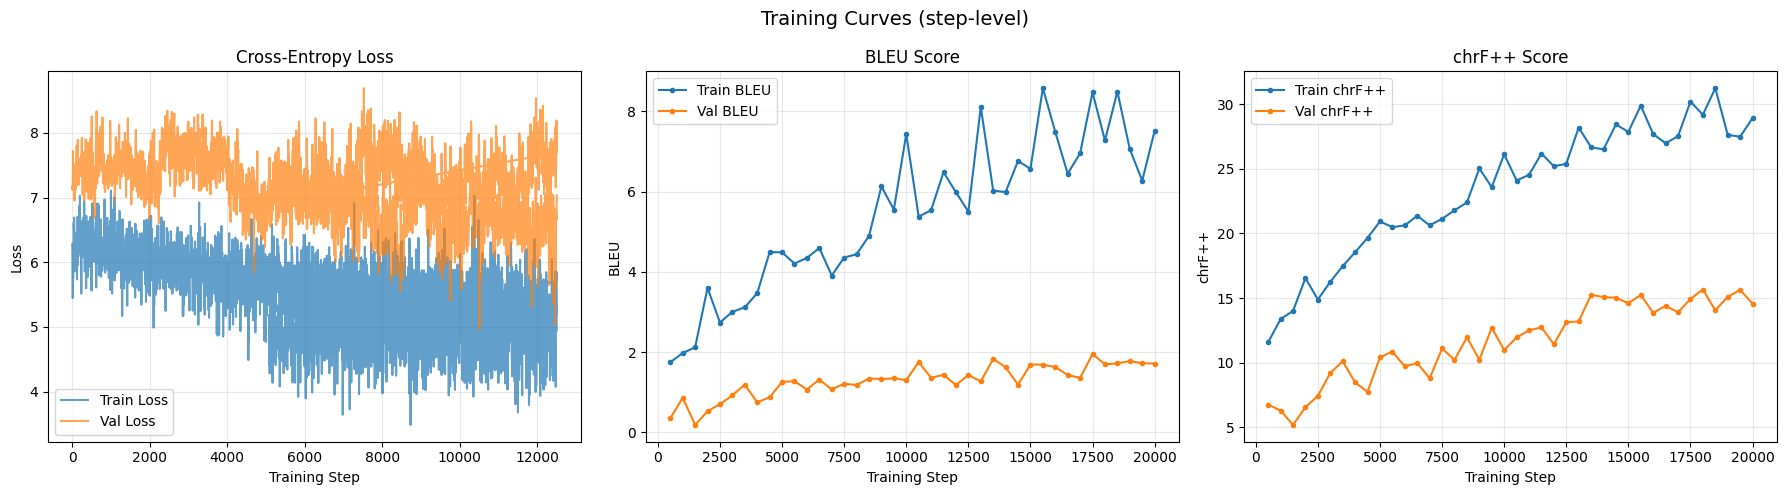

Plot saved to training_curves_bert.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Curves (step-level)', fontsize=14)

#  Loss 
axes[0].plot(loss_x, train_loss_steps, label='Train Loss', alpha=0.7)
axes[0].plot(loss_x, val_loss_steps,   label='Val Loss',   alpha=0.7)
axes[0].set_title('Cross-Entropy Loss')
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#  BLEU :
axes[1].plot(metric_x, train_bleu_steps, label='Train BLEU', marker='o', markersize=3)
axes[1].plot(metric_x, val_bleu_steps,   label='Val BLEU',   marker='o', markersize=3)
axes[1].set_title('BLEU Score')
axes[1].set_xlabel('Training Step')
axes[1].set_ylabel('BLEU')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# chrF++ :
axes[2].plot(metric_x, train_chrf_steps, label='Train chrF++', marker='o', markersize=3)
axes[2].plot(metric_x, val_chrf_steps,   label='Val chrF++',   marker='o', markersize=3)
axes[2].set_title('chrF++ Score')
axes[2].set_xlabel('Training Step')
axes[2].set_ylabel('chrF++')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_bert.png', dpi=1500, bbox_inches='tight')
plt.show()
print("Plot saved to training_curves_bert.png")


In [68]:
import pickle

data = {
    "train_loss_steps": train_loss_steps,
    "val_loss_steps": val_loss_steps,
    "train_bleu_steps": train_bleu_steps,
    "val_bleu_steps": val_bleu_steps,
    "train_chrf_steps": train_chrf_steps,
    "val_chrf_steps": val_chrf_steps,
    "loss_x": loss_x,
    "metric_x": metric_x
}

# Save
with open("metrics_1_bert.pkl", "wb") as f:
    pickle.dump(data, f)

In [59]:
# print("metric_x:", metric_x)
# print("len metric_x:", len(metric_x))
# print("len train_bleu_steps:", len(train_bleu_steps))

# # Check for non-monotonic steps
# for i in range(1, len(metric_x)):
#     if metric_x[i] <= metric_x[i-1]:
#         print(f" Non-monotonic at index {i}: {metric_x[i-1]} → {metric_x[i]}")

metric_x: [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]
len metric_x: 40
len train_bleu_steps: 40
 Non-monotonic at index 25: 12500 → 5500


In [62]:
metric_x[26] + (13000-5500)

13500

In [63]:
for i in range(25, len(metric_x)):
    metric_x[i] += (13000-5500)

In [ ]:
#  Final test evaluation :
model.load_state_dict(torch.load('tuta-model.pt'))
test_loss, test_bleu, test_chrf = compute_metrics(
    model, test_iterator, criterion, n_batches=100, device=device)

print(f'| Test Loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):7.3f} |')
print(f'| Test BLEU: {test_bleu:.2f} | Test chrF++: {test_chrf:.2f} |')


C:\Users\Saloni_major\AppData\Local\Temp\ipykernel_25300\2710822473.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('tuta-model.pt'))
Th

| Test Loss: 5.476 | Test PPL: 238.937 |
| Test BLEU: 8.58 | Test chrF++: 36.96 |


In [67]:
model.load_state_dict(torch.load('tuta-model.pt'))
test_loss = evaluate(model, test_iterator, criterion)
print(f'| Test Loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):7.3f} |')

C:\Users\Saloni_major\AppData\Local\Temp\ipykernel_25300\947942910.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('tuta-model.pt'))


| Test Loss: 6.566 | Test PPL: 710.806 |


# old

In [32]:
from tqdm import tqdm
def train(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0

    for i, (src, trg) in tqdm(enumerate(iterator)):
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()
        output = model(src, trg)

        # output = [trg len, batch size, output dim]
        # trg    = [trg len, batch size]
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        trg    = trg[1:].view(-1)

        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

In [33]:
def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for i, (src, trg) in enumerate(iterator):
            src = src.to(device)
            trg = trg.to(device)

            output     = model(src, trg, 0)  # no teacher forcing
            output_dim = output.shape[-1]
            output     = output[1:].view(-1, output_dim)
            trg        = trg[1:].view(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

In [34]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [35]:
N_EPOCHS = 2
CLIP     = 1

best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train(model, train_iterator, optimizer, criterion, CLIP)
    valid_loss = evaluate(model, valid_iterator, criterion)

    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tuta-model.pt')

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

3258it [1:37:09,  1.79s/it]


KeyboardInterrupt: 

In [ ]:
model.load_state_dict(torch.load('tuta-model.pt'))
test_loss = evaluate(model, test_iterator, criterion)
print(f'| Test Loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):7.3f} |')